Observed items: ['WL']
Simulated items: ['Surface elevation (716498.000000, 3124483.000000)', 'Surface elevation (692225.000000, 3100984.000000)', 'Surface elevation (665938.000000, 3041543.000000)', 'Surface elevation (652030.000000, 2965694.000000)', 'Surface elevation (664264.000000, 2967510.000000)']
R² = 0.021 | RMSE = 0.095 m | MAE = 0.074 m | Bias = 0.025 m


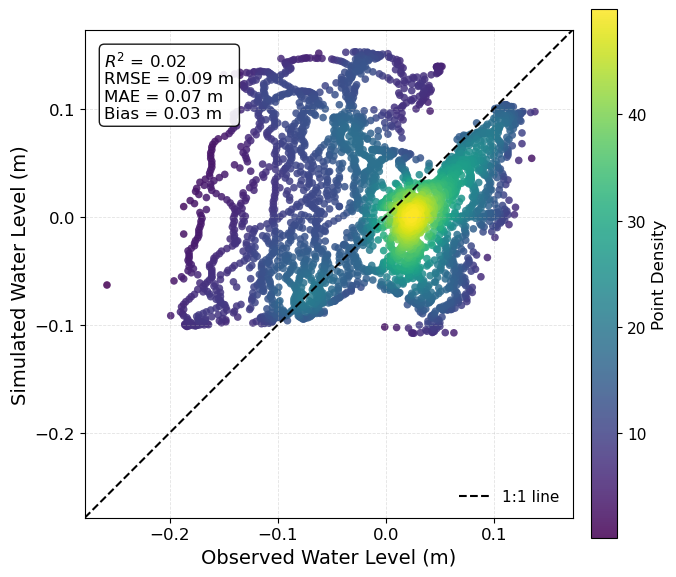

In [3]:
import mikeio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# File paths
obs_file = r"D:\Phd Research\Prototype HD Model\Measured WL\Aransas wildlife refuge JUL 2022.dfs0"
sim_file = r"D:\Phd Research\Prototype HD Model\Simulation\July_2022.m21fm - Result Files\simulated_aransas_rockport_Sbird_Rincon.dfs0"

# Read data
obs_df = mikeio.read(obs_file).to_dataframe()
sim_df = mikeio.read(sim_file).to_dataframe()

# Check item names
print("Observed items:", obs_df.columns.tolist())
print("Simulated items:", sim_df.columns.tolist())

# Select observed and simulated WL (Python index 0 = MIKE item 1)
obs = obs_df.iloc[:, 0].loc["2022-07-01":"2022-07-15 23:59:59"]
sim = sim_df.iloc[:, 0].loc["2022-07-01":"2022-07-15 23:59:59"]

# Interpolate simulated data to observed timestamps
sim_interp = sim.reindex(sim.index.union(obs.index)).sort_index().interpolate(method="time").reindex(obs.index)

# Combine and remove missing values
df = pd.DataFrame({"Observed": obs, "Simulated": sim_interp}).replace([np.inf, -np.inf], np.nan).dropna()
x, y = df["Observed"].values, df["Simulated"].values

# Performance statistics
r = np.corrcoef(x, y)[0, 1]
r2 = r**2
rmse = np.sqrt(np.mean((y - x)**2))
mae = np.mean(np.abs(y - x))
bias = np.mean(y - x)

print(f"R² = {r2:.3f} | RMSE = {rmse:.3f} m | MAE = {mae:.3f} m | Bias = {bias:.3f} m")

# KDE point density
xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy)
idx = density.argsort()
x_plot, y_plot, density_plot = x[idx], y[idx], density[idx]

# Plot limits
vmin, vmax = min(x.min(), y.min()), max(x.max(), y.max())
pad = 0.05 * (vmax - vmin)
vmin, vmax = vmin - pad, vmax + pad

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(x_plot, y_plot, c=density_plot, cmap="viridis", s=30, alpha=0.85, edgecolors="none")
ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1.5, label="1:1 line")

# Formatting
ax.set(xlim=(vmin, vmax), ylim=(vmin, vmax), xlabel="Observed Water Level (m)", ylabel="Simulated Water Level (m)")
ax.set_aspect("equal", adjustable="box")
ax.tick_params(labelsize=12)
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
ax.grid(True, ls="--", lw=0.6, alpha=0.35)
ax.legend(loc="lower right", fontsize=11, frameon=False)

# Statistics
stats = f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.2f} m\nMAE = {mae:.2f} m\nBias = {bias:.2f} m"
ax.text(0.04, 0.96, stats, transform=ax.transAxes, fontsize=12, va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

# Colorbar
cbar = fig.colorbar(sc, ax=ax, pad=0.03)
cbar.set_label("Point Density", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

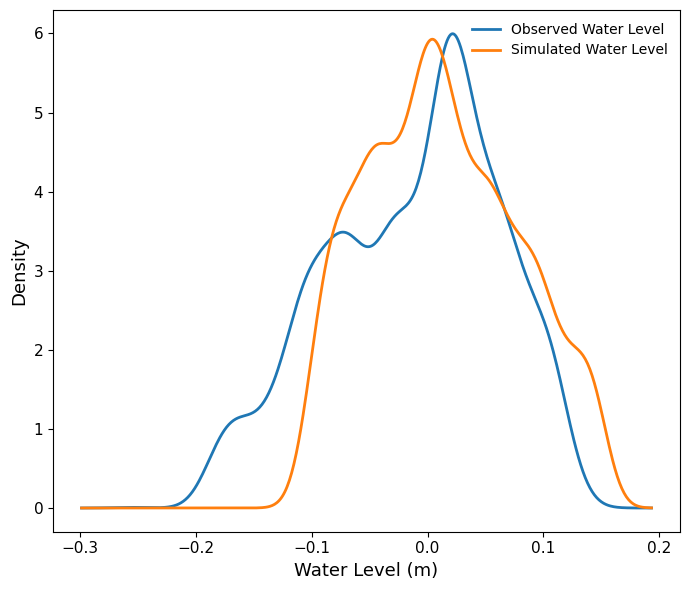

In [9]:
import mikeio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# File paths
obs_file = r"D:\Phd Research\Prototype HD Model\Measured WL\Aransas wildlife refuge JUL 2022.dfs0"
sim_file = r"D:\Phd Research\Prototype HD Model\Simulation\July_2022.m21fm - Result Files\simulated_aransas_rockport_Sbird_Rincon.dfs0"

# Read data
obs_df = mikeio.read(obs_file).to_dataframe()
sim_df = mikeio.read(sim_file).to_dataframe()

# Select observed and simulated WL
obs = obs_df.iloc[:, 0].loc["2022-07-01":"2022-07-15 23:59:59"]
sim = sim_df.iloc[:, 0].loc["2022-07-01":"2022-07-15 23:59:59"]   # MIKE item 1

# Interpolate simulated data to observed timestamps
sim_interp = sim.reindex(sim.index.union(obs.index)).sort_index().interpolate(method="time").reindex(obs.index)

# Combine and remove missing values
df = pd.DataFrame({"Observed": obs, "Simulated": sim_interp}).replace([np.inf, -np.inf], np.nan).dropna()
obs_values, sim_values = df["Observed"].values, df["Simulated"].values

# KDE
obs_kde = gaussian_kde(obs_values)
sim_kde = gaussian_kde(sim_values)

# Common x-range
xmin = min(obs_values.min(), sim_values.min())
xmax = max(obs_values.max(), sim_values.max())
pad = 0.1 * (xmax - xmin)
x = np.linspace(xmin - pad, xmax + pad, 500)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(x, obs_kde(x), lw=2, label="Observed Water Level")
ax.plot(x, sim_kde(x), lw=2, label="Simulated Water Level")

ax.set_xlabel("Water Level (m)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.tick_params(labelsize=11)
ax.legend(fontsize=10, frameon=False)
ax.grid(False)

plt.tight_layout()
plt.show()

Observed items: ['WL']
Simulated items: ['Surface elevation (716498.000000, 3124483.000000)', 'Surface elevation (692225.000000, 3100984.000000)', 'Surface elevation (665938.000000, 3041543.000000)', 'Surface elevation (652030.000000, 2965694.000000)', 'Surface elevation (664264.000000, 2967510.000000)']
R² = 0.113 | RMSE = 0.070 m | MAE = 0.064 m | Bias = 0.004 m


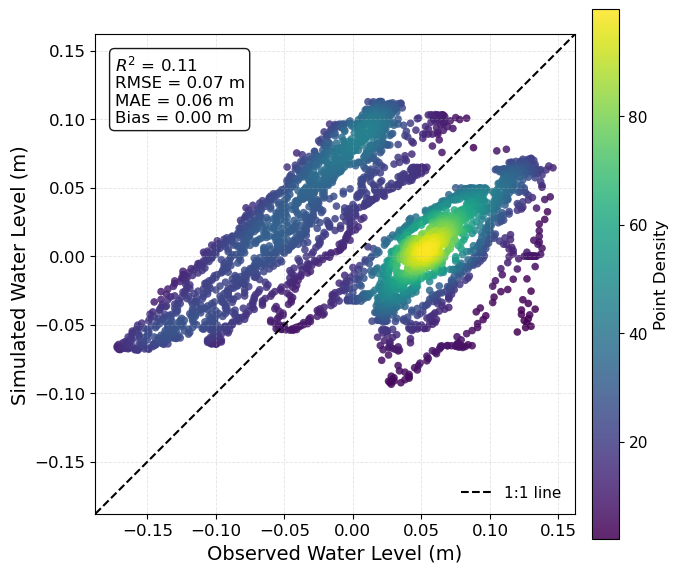

In [5]:
import mikeio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# File paths
obs_file = r"D:\Phd Research\Data\Water Level Data\Mike time series dfso\Rock Port July 2022.dfs0"
sim_file = r"D:\Phd Research\Prototype HD Model\Simulation\July_2022.m21fm - Result Files\simulated_aransas_rockport_Sbird_Rincon.dfs0"

# Read data
obs_df = mikeio.read(obs_file).to_dataframe()
sim_df = mikeio.read(sim_file).to_dataframe()

# Check item names
print("Observed items:", obs_df.columns.tolist())
print("Simulated items:", sim_df.columns.tolist())

# Select observed and simulated WL (Python index 0 = MIKE item 1)
obs = obs_df.iloc[:, 0].loc["2022-07-01":"2022-07-15 23:59:59"]
sim = sim_df.iloc[:, 1].loc["2022-07-01":"2022-07-15 23:59:59"]

# Interpolate simulated data to observed timestamps
sim_interp = sim.reindex(sim.index.union(obs.index)).sort_index().interpolate(method="time").reindex(obs.index)

# Combine and remove missing values
df = pd.DataFrame({"Observed": obs, "Simulated": sim_interp}).replace([np.inf, -np.inf], np.nan).dropna()
x, y = df["Observed"].values, df["Simulated"].values

# Performance statistics
r = np.corrcoef(x, y)[0, 1]
r2 = r**2
rmse = np.sqrt(np.mean((y - x)**2))
mae = np.mean(np.abs(y - x))
bias = np.mean(y - x)

print(f"R² = {r2:.3f} | RMSE = {rmse:.3f} m | MAE = {mae:.3f} m | Bias = {bias:.3f} m")

# KDE point density
xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy)
idx = density.argsort()
x_plot, y_plot, density_plot = x[idx], y[idx], density[idx]

# Plot limits
vmin, vmax = min(x.min(), y.min()), max(x.max(), y.max())
pad = 0.05 * (vmax - vmin)
vmin, vmax = vmin - pad, vmax + pad

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(x_plot, y_plot, c=density_plot, cmap="viridis", s=30, alpha=0.85, edgecolors="none")
ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1.5, label="1:1 line")

# Formatting
ax.set(xlim=(vmin, vmax), ylim=(vmin, vmax), xlabel="Observed Water Level (m)", ylabel="Simulated Water Level (m)")
ax.set_aspect("equal", adjustable="box")
ax.tick_params(labelsize=12)
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
ax.grid(True, ls="--", lw=0.6, alpha=0.35)
ax.legend(loc="lower right", fontsize=11, frameon=False)

# Statistics
stats = f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.2f} m\nMAE = {mae:.2f} m\nBias = {bias:.2f} m"
ax.text(0.04, 0.96, stats, transform=ax.transAxes, fontsize=12, va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

# Colorbar
cbar = fig.colorbar(sc, ax=ax, pad=0.03)
cbar.set_label("Point Density", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

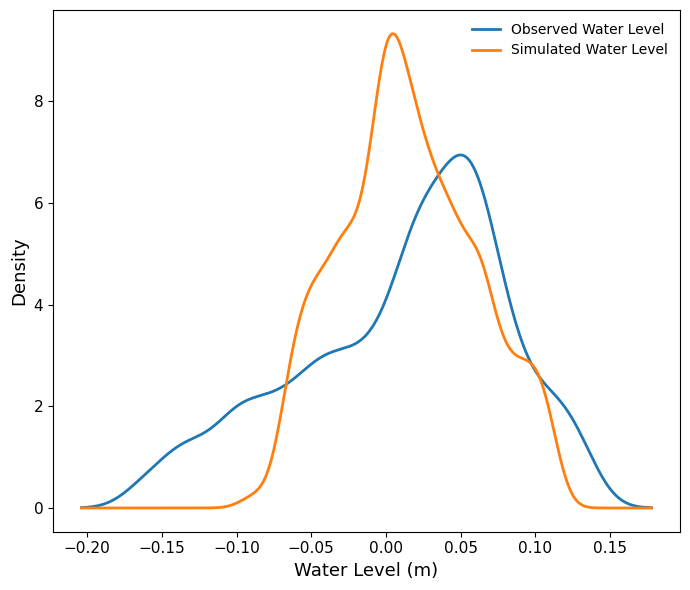

In [10]:
import mikeio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# File paths
obs_file = r"D:\Phd Research\Data\Water Level Data\Mike time series dfso\Rock Port July 2022.dfs0"
sim_file = r"D:\Phd Research\Prototype HD Model\Simulation\July_2022.m21fm - Result Files\simulated_aransas_rockport_Sbird_Rincon.dfs0"

# Read data
obs_df = mikeio.read(obs_file).to_dataframe()
sim_df = mikeio.read(sim_file).to_dataframe()

# Select observed and simulated WL
obs = obs_df.iloc[:, 0].loc["2022-07-01":"2022-07-15 23:59:59"]
sim = sim_df.iloc[:, 1].loc["2022-07-01":"2022-07-15 23:59:59"]   # MIKE item 1

# Interpolate simulated data to observed timestamps
sim_interp = sim.reindex(sim.index.union(obs.index)).sort_index().interpolate(method="time").reindex(obs.index)

# Combine and remove missing values
df = pd.DataFrame({"Observed": obs, "Simulated": sim_interp}).replace([np.inf, -np.inf], np.nan).dropna()
obs_values, sim_values = df["Observed"].values, df["Simulated"].values

# KDE
obs_kde = gaussian_kde(obs_values)
sim_kde = gaussian_kde(sim_values)

# Common x-range
xmin = min(obs_values.min(), sim_values.min())
xmax = max(obs_values.max(), sim_values.max())
pad = 0.1 * (xmax - xmin)
x = np.linspace(xmin - pad, xmax + pad, 500)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(x, obs_kde(x), lw=2, label="Observed Water Level")
ax.plot(x, sim_kde(x), lw=2, label="Simulated Water Level")

ax.set_xlabel("Water Level (m)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.tick_params(labelsize=11)
ax.legend(fontsize=10, frameon=False)
ax.grid(False)

plt.tight_layout()
plt.show()

Observed items: ['WL']
Simulated items: ['Surface elevation (649450.000000, 3019930.000000)']
R² = 0.317 | RMSE = 0.102 m | MAE = 0.080 m | Bias = 0.066 m


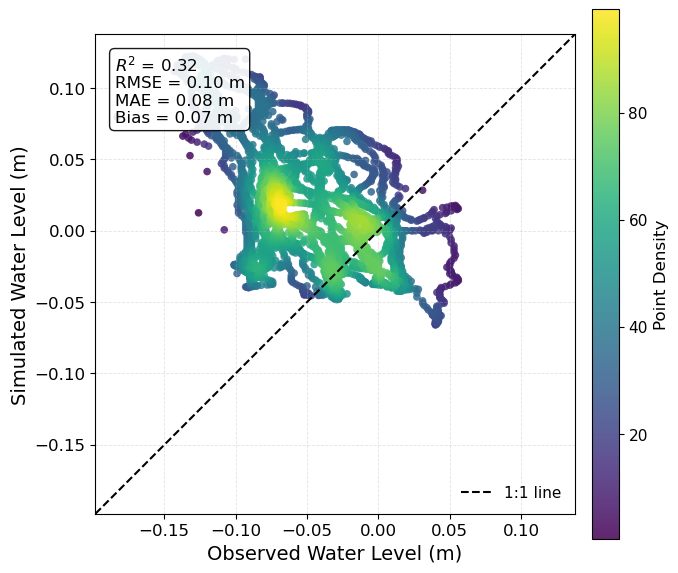

In [7]:
import mikeio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# File paths
obs_file = r"D:\Phd Research\Data\Water Level Data\Mike time series dfso\Baffin_Bay_8776604.dfs0"
sim_file = r"D:\Phd Research\Prototype HD Model\Simulation\July_2022.m21fm - Result Files\simulated_baffin_bay_8776604.dfs0"

# Read data
obs_df = mikeio.read(obs_file).to_dataframe()
sim_df = mikeio.read(sim_file).to_dataframe()

# Check item names
print("Observed items:", obs_df.columns.tolist())
print("Simulated items:", sim_df.columns.tolist())

# Select observed and simulated WL (Python index 0 = MIKE item 1)
obs = obs_df.iloc[:, 0].loc["2022-07-01":"2022-07-15 23:59:59"]
sim = sim_df.iloc[:, 0].loc["2022-07-01":"2022-07-15 23:59:59"]

# Interpolate simulated data to observed timestamps
sim_interp = sim.reindex(sim.index.union(obs.index)).sort_index().interpolate(method="time").reindex(obs.index)

# Combine and remove missing values
df = pd.DataFrame({"Observed": obs, "Simulated": sim_interp}).replace([np.inf, -np.inf], np.nan).dropna()
x, y = df["Observed"].values, df["Simulated"].values

# Performance statistics
r = np.corrcoef(x, y)[0, 1]
r2 = r**2
rmse = np.sqrt(np.mean((y - x)**2))
mae = np.mean(np.abs(y - x))
bias = np.mean(y - x)

print(f"R² = {r2:.3f} | RMSE = {rmse:.3f} m | MAE = {mae:.3f} m | Bias = {bias:.3f} m")

# KDE point density
xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy)
idx = density.argsort()
x_plot, y_plot, density_plot = x[idx], y[idx], density[idx]

# Plot limits
vmin, vmax = min(x.min(), y.min()), max(x.max(), y.max())
pad = 0.05 * (vmax - vmin)
vmin, vmax = vmin - pad, vmax + pad

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(x_plot, y_plot, c=density_plot, cmap="viridis", s=30, alpha=0.85, edgecolors="none")
ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1.5, label="1:1 line")

# Formatting
ax.set(xlim=(vmin, vmax), ylim=(vmin, vmax), xlabel="Observed Water Level (m)", ylabel="Simulated Water Level (m)")
ax.set_aspect("equal", adjustable="box")
ax.tick_params(labelsize=12)
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
ax.grid(True, ls="--", lw=0.6, alpha=0.35)
ax.legend(loc="lower right", fontsize=11, frameon=False)

# Statistics
stats = f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.2f} m\nMAE = {mae:.2f} m\nBias = {bias:.2f} m"
ax.text(0.04, 0.96, stats, transform=ax.transAxes, fontsize=12, va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

# Colorbar
cbar = fig.colorbar(sc, ax=ax, pad=0.03)
cbar.set_label("Point Density", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

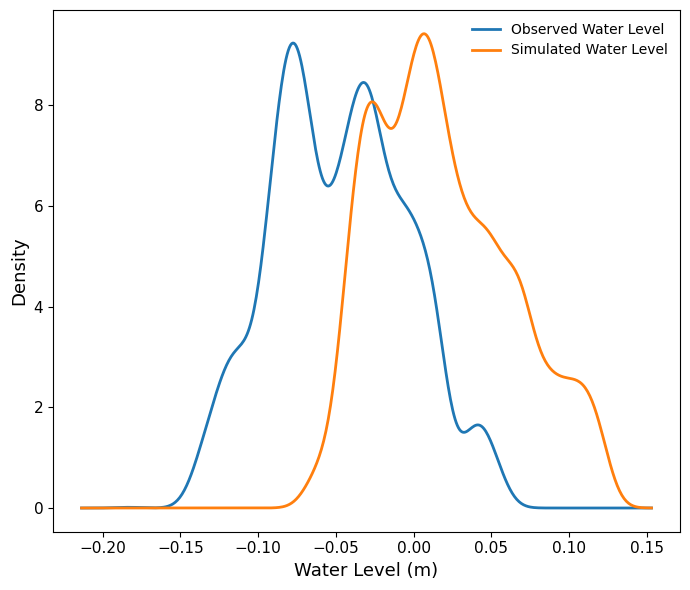

In [11]:
import mikeio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# File paths
obs_file = r"D:\Phd Research\Data\Water Level Data\Mike time series dfso\Baffin_Bay_8776604.dfs0"
sim_file = r"D:\Phd Research\Prototype HD Model\Simulation\July_2022.m21fm - Result Files\simulated_baffin_bay_8776604.dfs0"

# Read data
obs_df = mikeio.read(obs_file).to_dataframe()
sim_df = mikeio.read(sim_file).to_dataframe()

# Select observed and simulated WL
obs = obs_df.iloc[:, 0].loc["2022-07-01":"2022-07-15 23:59:59"]
sim = sim_df.iloc[:, 0].loc["2022-07-01":"2022-07-15 23:59:59"]   # MIKE item 1

# Interpolate simulated data to observed timestamps
sim_interp = sim.reindex(sim.index.union(obs.index)).sort_index().interpolate(method="time").reindex(obs.index)

# Combine and remove missing values
df = pd.DataFrame({"Observed": obs, "Simulated": sim_interp}).replace([np.inf, -np.inf], np.nan).dropna()
obs_values, sim_values = df["Observed"].values, df["Simulated"].values

# KDE
obs_kde = gaussian_kde(obs_values)
sim_kde = gaussian_kde(sim_values)

# Common x-range
xmin = min(obs_values.min(), sim_values.min())
xmax = max(obs_values.max(), sim_values.max())
pad = 0.1 * (xmax - xmin)
x = np.linspace(xmin - pad, xmax + pad, 500)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(x, obs_kde(x), lw=2, label="Observed Water Level")
ax.plot(x, sim_kde(x), lw=2, label="Simulated Water Level")

ax.set_xlabel("Water Level (m)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.tick_params(labelsize=11)
ax.legend(fontsize=10, frameon=False)
ax.grid(False)

plt.tight_layout()
plt.show()